In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00


In [ ]:
import kagglehub
from tqdm.auto import tqdm

# Download latest version
path = kagglehub.dataset_download("kushagrapandya/visdrone-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.10G/2.10G [01:12<00:00, 31.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1


In [5]:
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone.yaml
/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/annotations/9999973_00000_d_0000015.txt
/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/annotations/0000074_14850_d_0000029.txt
/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/annotations/9999938_00000_d_0000027.txt
/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/annotations/0000337_01500_d_0000039.txt
/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/annotations/9999973_00000_d_0000034.txt
/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/V

In [ ]:
model = YOLO('yolov8m.pt')

results = model.train(
    data=path + '/VisDrone.yaml',
    epochs=40,
    imgsz=736,
    batch=12,
    optimizer='AdamW',
    lr0=1e-4,
    lrf=0.01,
    cos_lr=True,
    freeze=8,
    patience=5,
    augment=True,
    plots=True,
    save=True,
    project='/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m',
    name='stage1_frozen'
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/visdrone-dataset/VisDrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=8, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage1_frozen, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, perspect

Converting /content/datasets/VisDrone/VisDrone2019-DET-train: 6471it [00:38, 167.17it/s]
Converting /content/datasets/VisDrone/VisDrone2019-DET-val: 548it [00:04, 114.16it/s]
Converting /content/datasets/VisDrone/VisDrone2019-DET-test-dev: 1610it [00:07, 204.95it/s]

Dataset download success ✅ (145.8s), saved to /content/datasets



Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

In [ ]:
state_path = '/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage1_frozen/weights/best.pt'
model = YOLO(state_path)

results = model.train(
    data=path + '/VisDrone.yaml',
    epochs=40,
    imgsz=736,
    batch=12,
    optimizer='AdamW',
    lr0=5e-5,
    lrf=0.01,
    weight_decay=5e-4,
    label_smoothing=0.05,
    cos_lr=True,
    freeze=4,
    patience=7,
    augment=True,
    plots=True,
    save=True,
    project='/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m',
    name='stage2_frozen'
)


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=4, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage1

Converting /content/datasets/VisDrone/VisDrone2019-DET-train: 6471it [00:35, 184.20it/s]
Converting /content/datasets/VisDrone/VisDrone2019-DET-val: 548it [00:04, 117.21it/s]
Converting /content/datasets/VisDrone/VisDrone2019-DET-test-dev: 1610it [00:07, 208.57it/s]

Dataset download success ✅ (78.6s), saved to /content/datasets




                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics.nn.modules.conv.Conv             [384

In [ ]:
state_path = '/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage2_frozen/weights/best.pt'
model = YOLO(state_path)

results = model.train(
    data=path + '/VisDrone.yaml',
    epochs=40,
    imgsz=736,
    batch=12,
    optimizer='AdamW',
    lr0=2e-5,
    lrf=0.01,
    weight_decay=1e-4,    # регуляризация
    cos_lr=True,          # scheduler
    patience=7,
    augment=False,        # убираем сильные аугментации
    plots=True,
    save=True,

    project='/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m',
    name='stage3'
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/root/.cache/kagglehub/datasets/kushagrapandya/visdrone-dataset/versions/1/VisDrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=2e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage2_frozen/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

Converting /content/datasets/VisDrone/VisDrone2019-DET-train: 6471it [00:36, 175.82it/s]
Converting /content/datasets/VisDrone/VisDrone2019-DET-val: 548it [00:05, 107.35it/s]
Converting /content/datasets/VisDrone/VisDrone2019-DET-test-dev: 1610it [00:07, 204.02it/s]

Dataset download success ✅ (111.8s), saved to /content/datasets




                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics.nn.modules.conv.Conv             [384

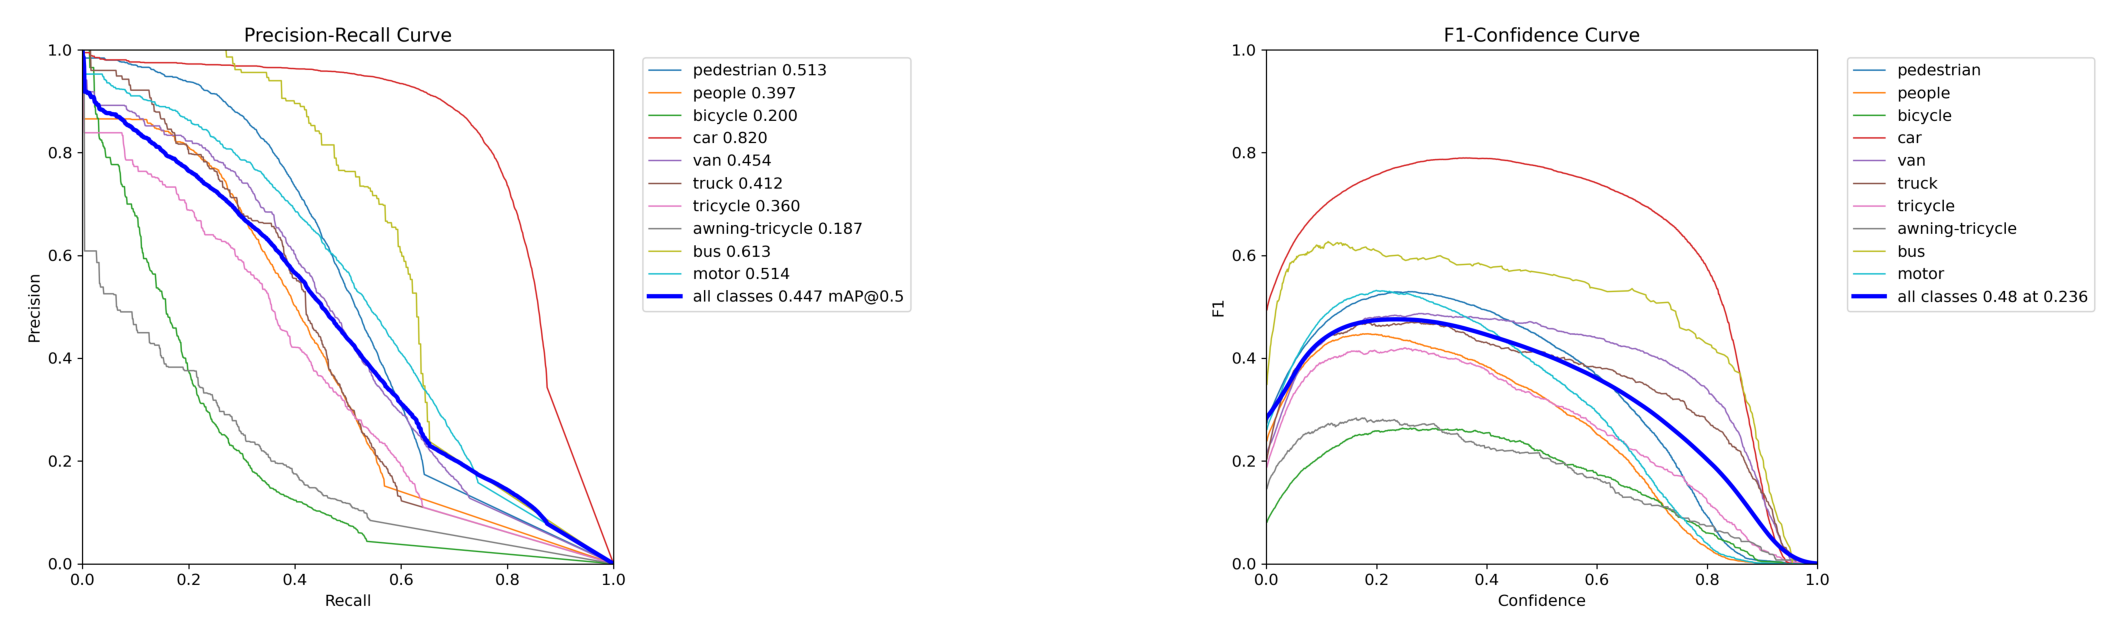

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(28, 8))
plt.subplot(1, 2, 1)
img = Image.open('/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage3/BoxPR_curve.png')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
img = Image.open('/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage3/BoxF1_curve.png')
plt.imshow(img)
plt.axis('off');


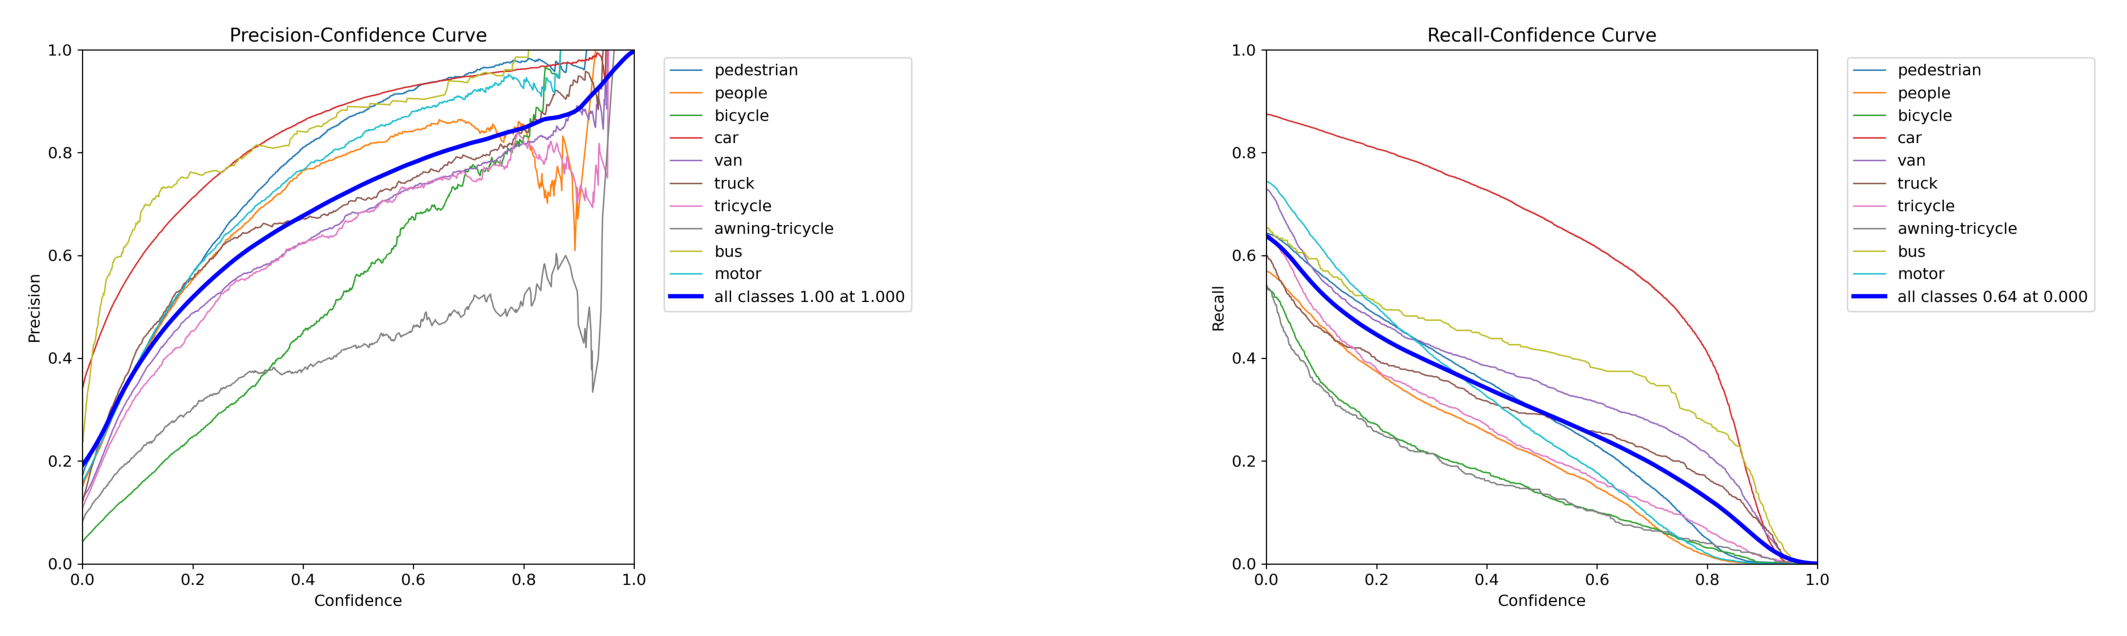

In [3]:
plt.figure(figsize=(28, 8))
plt.subplot(1, 2, 1)
img = Image.open('/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage3/BoxP_curve.png')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
img = Image.open('/content/drive/MyDrive/DLS_PROJECT/DETECTION/YOLOv8m/stage3/BoxR_curve.png')
plt.imshow(img)
plt.axis('off');